In [43]:
import os
from dotenv import load_dotenv
import databento as db
import pandas as pd

load_dotenv()
client = db.Historical(os.environ.get("DATABENTO_API_KEY"))

In [ ]:
# !!!ONLY RUN IF THERE IS NO EXISTING DATA IN /data OR IF YOU WANT NEW DATA!!!
data = client.timeseries.get_range(
    dataset="XNAS.ITCH",
    symbols="INTC",
    schema="trades",
    start="2023-01-01",
    end="2026-01-01",
    path="../data/INTC_trades(XNASITCH).dbn.zst",
)

store = db.DBNStore.from_file("../data/INTC_trades(XNASITCH).dbn.zst")
store.to_parquet("../data/INTC_trades(XNASITCH).parquet")

In [50]:
# Define a daily_rv function that takes df and freq and returns a DataFrame with daily realized volatility

def clean_trades(raw, tz="America/New_York", start="09:30:00", end="16:00:00"):
    """Keep valid trades, index by exchange timestamp in local tz, restrict to RTH."""
    df = raw[(raw["price"] > 0) & (raw["size"] > 0)].copy()
    df = df.set_index("ts_event")
    df.index = df.index.tz_convert(tz)
    return df.between_time(start, end)

def daily_rv(df, freq):
    day = df.index.normalize()
    prices = (
        df["price"]
        .groupby(day)
        .resample(freq)
        .last()
        .ffill()
        .droplevel(0)
    )

    #Get opening price for each day
    opens = df["price"].groupby(day).first()

    #Add openings to resampled prices
    prices = pd.concat([opens, prices]).sort_index()
    
    logp = np.log(prices)

    rv_daily = (
        logp.groupby(logp.index.normalize())
        .apply(lambda x: (x.diff() ** 2).sum())
    )

    return rv_daily

In [51]:
# Create a df that contains the daily realized volatility for each frequency in freqs

freqs = ["100ms", "200ms", "500ms", "1s", "2s", "5s", "10s", "30s", "1min", "2min", "5min", "10min", "30min"]

parts = []

for month in pd.date_range("2023-01", "2023-12", freq="MS", tz="UTC"):
    raw = pd.read_parquet(
        "../data/INTC_trades(XNASITCH).parquet",
        columns=["ts_event", "price", "size"],
        filters=[("ts_event", ">=", month),
                 ("ts_event", "<",  month + pd.offsets.MonthBegin(1))],
    )

    df = clean_trades(raw)
    parts.append(pd.DataFrame({f: daily_rv(df, f) for f in freqs}))

rv = pd.concat(parts)

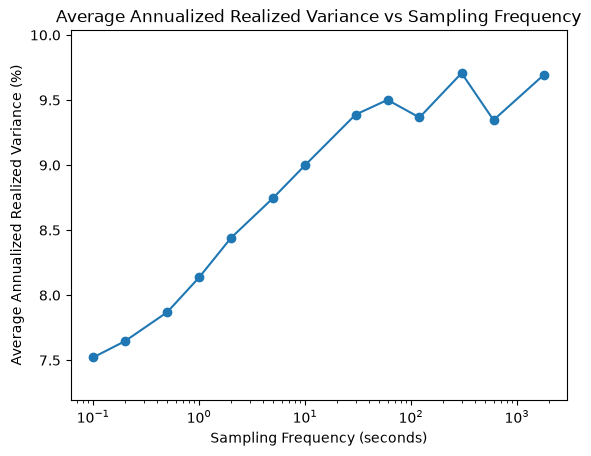

In [52]:
import matplotlib.pyplot as plt

seconds = [0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120, 300, 600, 1800]

rv_ann = rv.mean() * 252 * 100  # # variance units, annualized, in %

plt.semilogx(seconds, rv_ann, marker="o")
plt.margins(y=0.15) 
plt.xlabel("Sampling Frequency (seconds)")
plt.ylabel("Average Annualized Realized Variance (%)")
plt.title("Average Annualized Realized Variance vs Sampling Frequency")
plt.show()